## Packaging And Reuse

**The Core Concept: What is an Accelerator?**

The most expensive part of engineering is rebuilding the same solution from scratch for every new customer. An accelerator solves this by packaging a working solution (like an agent loop, an MCP server, or an eval) so that future engagements start from a solid foundation rather than a blank repository.

The Strategy: Separate the reusable core of the build from the customer-specific code. Expose the customer-specific parts as parameters with documented defaults, allowing the next team to simply configure the asset rather than rewrite it.

**Three Main Types of Reusable Assets**

Different types of work require different packaging approaches. Reaching for the wrong type makes an asset look reusable but difficult to actually apply.

- **_Agent Templates_**
    - What it bundles: The system prompt, tool schemas, and the loop structure from a working agent.
    - How to package: Extract domain-specific values (prompts, paths, scopes, credentials, thresholds) into configuration files with documented defaults.
    - Example: Instead of hardcoding values directly into the loop, use parameters so a new team sets the values without needing to edit the core loop logic.

- **_MCP Server Packages_**
    - What it bundles: The tools the server exposes, their inputs, and the scope controlled by the installing team.
    - How to package: Document each tool input clearly and allow the installing team to define the scope. This ensures the server can be installed into a new environment without altering the code.

- **_Eval Suites_**
    - What it bundles: The graded test set and the judge rubric that prove the asset actually works.
    - How to package: Ship the dataset and rubric together. This allows a new team to run them in their specific context to confirm the asset works. It also acts as a deployment gate (testing new model versions against a pinned baseline before they go live).

**Critical Packaging Requirements**

To ensure an asset isn't treated as a "black box" that gets discarded and rebuilt, it must include two critical non-code components:

- **1. Documentation of Assumptions**
Code only describes behavior. You must document what a future builder cannot infer just by reading the code:
    - Assumptions the asset makes about its environment.
    - The exact inputs it expects.
    - The failure modes it is already programmed to handle.
    - The evaluation criteria that define whether it is "working."

- **2. Audit Logs for Security**
An accelerator without an audit log will fail its first enterprise security review. The package must document and bundle:
    - What data the asset touches.
    - The identity the asset acts under.
    - An immutable log of what the asset did.

**Key Takeaways & Trade-offs**
- The Anti-Pattern: The most common mistake is shipping an agent as a set of loose scripts. While they run, customer-specific values are buried throughout different files, forcing the next team to copy and diverge the code instead of configuring a single asset.

- The Trade-off: Parameterizing and documenting adds real cost and complexity to the initial build. However, it turns one delivery into an asset that the next engagement can configure in hours.

- When to skip it: If you are building a one-off solution that a customer will never reuse, the overhead of packaging is not worth it—just ship the build and move on.

## Contributing Back

**Moving Assets to Shared Infrastructure**

The page focuses on how to take an internal, packaged asset and contribute it to shared infrastructure (like the Claude Cookbook or open-source MCP repositories) so that a maintainer will actually accept it.

The good news is that if you properly packaged the asset for your own team (by extracting parameters, documenting assumptions, and bundling an eval), it is already close to being contribution-ready.

**The Four Rules for Verification**

Maintainers will only accept a contribution they can easily verify. To clear the technical review bar, your contribution must include:

- A Single Focus: The code should do exactly one thing. Sprawling, multi-component applications will stall in review because the maintainer has to reconstruct your intent.

- A Runnable Example: A reviewer should not have to build their own test harness to see your code in action.

- A Functional Test: A test proves the behavior works as intended without requiring the maintainer to reproduce your underlying reasoning.

- Documented Assumptions: A short statement defining the environment and assumptions, ensuring the maintainer isn't stuck troubleshooting the first failure.

**Matching the Channel and Clearing Legal Gates**

- Pick the Right Channel: Put the contribution where it belongs. For example, the Claude Cookbook is for focused, end-to-end reference implementations, while individual tools or servers have their own specific repositories.

- Licensing Comes First: Before any technical review begins, you must clear licensing and attribution. You must confirm that you have the legal right to contribute code generated during a customer engagement, and you must properly attribute any prior work. If a licensing constraint cannot be cleared, the code should not be contributed.

## Requirements & Lifecycle

This section explains how to bridge the gap between high-level business goals and concrete technical decisions by establishing checkable functional and infrastructure requirements.

**1. Capturing Functional Requirements**

- Definition: A functional requirement defines what the system must do with enough specific detail to verify.

- Example:
    - Vague Business Problem: "Help support agents answer faster."
    - Checkable Functional Requirements: "Classify each ticket into one of four queues; draft a reply citing the relevant policy; never auto-send without human approval."

- Purpose: Transforming loose goals into specific behaviors provides clear criteria for testing (evals) and stakeholder reviews.

**2. Deriving Infrastructure Requirements**

- Definition: Non-functional constraints that the deployment platform must satisfy.

- Core Questions to Ask:

    - Latency: How fast must responses be, measured from the user's location?

    - Scale: What are the expected request volumes and peak loads?

    - Residency: Where must data be processed to comply with relevant regulations?

    - Identity: Who is acting, under what credentials, and what actions need auditing?

**3. Documenting for Defensibility**

- Creating a concise requirements record—covering functional behaviors, infrastructure constraints, and regulatory rules—allows teams to justify their platform choices objectively rather than relying solely on personal familiarity.

**When to Use This Approach**

- Handles Well: Moving systematically from a business problem to verifiable requirements before selecting a technology platform.

- Adds Cost/Complexity: Engaging in upfront scoping conversations that teams often try to skip.

- Alternative Approach: For lightweight, throwaway prototypes with no regulatory constraints or formal reviews, simple notes are sufficient.

## Systems Lifecycle for Claude applications

This section of the module maps the systems lifecycle onto AI development, framing individual engineering tasks within a structured, repeatable arc.

**The Lifecycle Phases Applied**

1. Requirements: Capture both functional needs (what the system must do) and infrastructure constraints (latency, data residency, scale).

2. Design: Select the appropriate platform, model, and trust boundaries.

3. Build: Write the necessary agent logic, tools, and prompts.

4. Test: Execute evaluations (evals), unit tests, integration tests, and end-to-end checks.

5. Deploy: Pin model and code versions, ensuring promotion is strictly gated on passing evaluations.

6. Operate: Instrument cost, latency, error tracking, and enforce runtime guardrails.

7. Iterate: Feed real-world production findings back into requirements.

**Gating Between Phases**
- A gate acts as a formal decision point required to move from one phase to the next. For instance, a team cannot advance from Design to Build until the platform satisfies data residency requirements, nor can they transition from Deploy to full production until the new version clears evaluation against a pinned baseline.

- Implementation Example: Version Promotion Gate
To illustrate a phase gate during deployment, consider a CI/CD pipeline script that blocks promotion to production unless the latest candidate evaluation meets a minimum score threshold against a baseline:

Python:

    def evaluate_and_promote(candidate_model, baseline_eval_score):
    # Run evaluation suite against pinned baseline
    current_eval_score = run_eval_suite(candidate_model)

    # Enforce the release gate
    if current_eval_score >= baseline_eval_score:
        print("Gate passed: Promoting model to production deployment.")
        deploy_to_production(candidate_model)
    else:
        raise ValueError(
            f"Gate failed: Score {current_eval_score} did not meet baseline {baseline_eval_score}."
        )

**When to Use This Approach**

- Handles Well: Placing each piece of engineering work in the correct lifecycle phase with defined artifacts and formal gates, ensuring compliance and reviewability in regulated deployments.

- Adds Cost or Complexity: Imposes strict checkpoints that teams working under tight deadlines are frequently tempted to skip.

- Alternative Approach: While one-off experimental prototypes may safely collapse or omit these phases, regulated production deployments require full adherence to the lifecycle.

## Deployment & Versioning

**1. Cloud-Driven Platform Selection**

Choosing where to run a Claude deployment is primarily determined by where a customer already maintains their infrastructure, identity controls, and compliance boundaries:

- **First-party Claude API**: Uses Anthropic’s native identity and infrastructure; typically gets new features first.

- **Claude Platform on AWS**: Uses Anthropic model IDs and lifecycle via an AWS account, but inference is operated by Anthropic outside the AWS boundary.

- **Claude in Amazon Bedrock**: Runs inside the customer's AWS compliance boundary, utilizing the Messages API (/anthropic/v1/messages) or legacy Converse/InvokeModel APIs.

- **Google Vertex AI**: Integrates directly into Google Cloud IAM and billing, supporting regional endpoints for data residency.

- **Third-Party Platforms** (e.g., Microsoft Foundry): Embeds Claude directly into host ecosystems (with options for hosting natively on Azure or on Anthropic).

**2. Version Pinning & Upstream Changes**

To prevent upstream model changes from introducing untracked behavior or regressions into production:

- Avoid Aliases: Generic or convenience model aliases (like claude-haiku-4-5) can change underlying behavior automatically.

- Pin Snapshots: Always target a specific model snapshot ID (e.g., claude-haiku-4-5-20251001 or specific platform version identifiers).

- Eval-Gated Rollouts: Model version promotions must be gated against standard evaluation suites before replacing baseline versions.

**Implementation Examples Across Deployment Platforms**

Below are examples showing how to pin model versions across the primary deployment environments:

**1. Direct Anthropic SDK (First-Party API / Claude Platform on AWS)**

    import anthropic
    client = anthropic.Anthropic()

    # ALWAYS: Pin to a specific snapshot ID rather than a generic model alias
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",  # Pinned snapshot ID
        max_tokens=1024,
        messages=[{"role": "user", "content": "Analyze system requirements."}]
    )

**2. Amazon Bedrock (Messages API Integration)**

    import boto3
    import json

    bedrock_runtime = boto3.client(service_name="bedrock-runtime", region_name="us-east-1")

    # ALWAYS: Use the explicit full model ID with the `anthropic.` prefix
    model_id = "anthropic.claude-3-5-sonnet-20241022-v2:0"

    body = json.dumps({
        "anthropic_version": "bedrock-2023-05-31",
        "max_tokens": 1024,
        "messages": [{"role": "user", "content": "Analyze system requirements."}]
    })

    response = bedrock_runtime.invoke_model(
        modelId=model_id,
        body=body
    )

**3. Google Vertex AI (GCP Native Integration)**

    from anthropic import AnthropicVertex

    # ALWAYS: Specify the fully defined model version within your project's region endpoint
    client = AnthropicVertex(region="us-central1", project_id="my-gcp-project")

    message = client.messages.create(
        model="claude-3-5-sonnet@20240620",  # Explicitly pinned Vertex model ID
        max_tokens=1024,
        messages=[{"role": "user", "content": "Analyze system requirements."}]
    )

**Key Trade-offs**

- Handles Well: Prevents silent downstream failures, ensures data residency compliance, and makes deployments fully repeatable and reviewable.

- Adds Complexity: Requires active version management, evaluation suites, and maintenance of fallback/rollback configurations for every production release.

- Alternative Approach: Unpinned aliases are acceptable for temporary, throwaway prototypes, but pinned snapshots are mandatory for shipping production systems.

## Comparing Platforms

When deploying an AI agent solution, choosing a platform (such as a first-party API or a cloud-hosted provider like Amazon Bedrock or Microsoft Foundry) requires evaluating three major dimensions to satisfy procurement and security teams:

**Latency:**

- The Trade-off: Running a platform in the customer’s local cloud region reduces round-trip time, whereas first-party endpoints often receive new features and capabilities earlier.

- Best Practice: Measure latency directly from the customer’s region against their actual payload rather than relying on measurements from a development laptop.

**Compliance**:

- The Trade-off: Compliance certifications, audit controls, and data residency rules are often pass-or-fail constraints for regulated industries (like finance or healthcare). For instance, EU data residency requirements dictate specific platform choices—such as Bedrock or Vertex AI—since third-party hosting models (like Azure-hosted Foundry vs. Anthropic-hosted Foundry) handle residency differently.

- Best Practice: Surface compliance constraints during initial scoping rather than at contract review.

**Cost**:

- The Trade-off: While per-token rates are often similar across platforms, the true total cost depends heavily on data egress fees, platform fees, and integration effort.

- Best Practice: Instrument and calculate the total cost per call for each platform rather than looking at token prices in isolation.

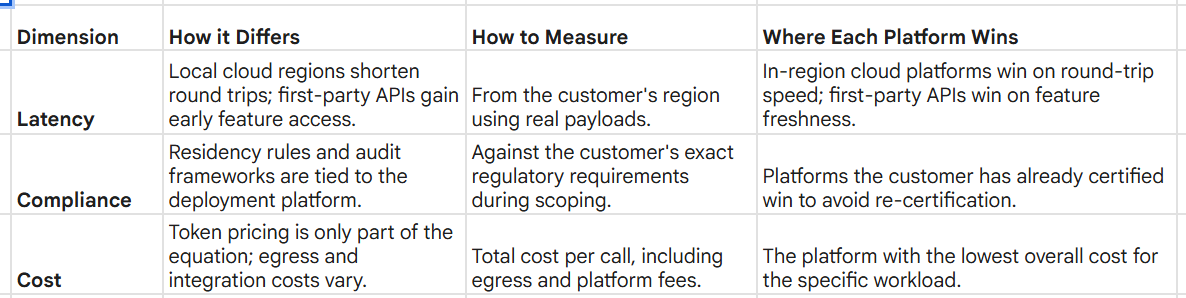

**The Familiar Platform Trap**

Choosing a deployment platform based solely on team familiarity optimizes for building fast rather than shipping successfully.

- What Happened: A developer built an integration on a familiar platform to meet a deadline. It passed functional tests, but failed the customer's data residency review at final sign-off, forcing a complete rebuild on an approved regional platform.

- Key Takeaway: For regulated customers, compliance and residency are pass-or-fail constraints. Identify them during initial scoping to avoid expensive late-stage rebuilds.

## Trust Boundaries

When building multi-component applications that connect different AI capabilities (e.g., an API orchestrator, an autonomous task agent, and an external system server), every connection between components introduces potential security risks. Maintaining trust boundaries under formal compliance reviews requires three core disciplines:

**Mapping Component Roles & Seams:**

- Multi-component workflows coordinate distinct capabilities (e.g., an API request triggering a Claude Code task that interacts with an external database).

 Every connection seam between these components can allow identity, secrets, or untrusted input to cross boundaries. Map these interactions before connecting any services.

**Treating Data Crossing Boundaries as Untrusted:**

- Trust boundaries exist wherever data or instructions move between deployment environments.

- Content fetched from external sources by one component must be treated strictly as data, not executable instructions, when passed downstream to another component. Never assume a downstream component is safe just because it worked properly in isolation.

**Applying System-Wide Least Privilege:**

- An application’s overall security is only as strong as its most privileged seam.

- Each component must be tightly scoped to the minimal permissions required for its role so that a compromised or steered component cannot access unauthorized external systems.

**Scoping for Regulated Reviews:**

- For enterprise and compliance reviews (e.g., HIPAA or Zero Data Retention constraints), platform selection matters. Managed cloud services like Amazon Bedrock or Google Cloud Vertex AI are typically chosen to satisfy strict audit logging and regional data-residency requirements.

**Concrete ExampleScenario:**

_Secure Customer Support Automation Workflow_

- The Setup: A financial services app uses a First-Party API to receive user support tickets. The API triggers a Claude Code Agent to search the web and extract external policy documentation, which is then sent to an MCP Server connected directly to the company’s internal customer database to log a resolution.
- The Security Boundary Risk:
- If the web document fetched by the Claude Code Agent contains malicious text (prompt injection), and the agent passes that payload directly to the MCP Server without validation, the untrusted input could manipulate the database integration.
- The Solution:
    - Seam 1 (API $\rightarrow$ Agent): Validate input parameters and execute under a restricted caller identity.
    - Seam 2 (Agent $\rightarrow$ MCP Server): Sanitize the fetched document and wrap it strictly as a non-executable data object (e.g., treat_as_data(fetched_content)) before passing it to the database call.
    - Seam 3 (MCP Server $\rightarrow$ Database): Restrict the MCP Server’s database role to read/append only on specific tables, logging every query for audit purposes.

In [1]:
# ❌ IMPERFECT IMPLEMENTATION

def build_code_auditor():
    return Agent(
        model="opus",                             # ❌ Ambiguous model identifier
        system_prompt=AUDIT_PROMPT,
        repo_path="/var/jenkins/workspace/app",   # ❌ Hardcoded local environment path
        tools=[read_file, run_linter]
    )

# ❌ Unpinned, unversioned deployment call
deploy(platform="amazon_bedrock", identity=aws_role_arn)

# ❌ Multi-component boundary flaw: untrusted network data passed directly downstream
untrusted_config = code_task.run(fetch_url=customer_repo_config_url)
next_stage_pipeline(input=untrusted_config)

In [ ]:
# ✅ REFACTORED & PRODUCTION-READY IMPLEMENTATION

def build_code_auditor(repo_path: str):  # Parameterized for multi-environment packaging
    return Agent(
        model="us.anthropic.claude-opus-4-8",  # Pinned explicit Bedrock model ID
        system_prompt=AUDIT_PROMPT,
        repo_path=repo_path,                   # Dynamic repository path input
        tools=[read_file, run_linter]
    )

# Pinned deployment with rollback and explicit version strategy
deploy(
    platform="amazon_bedrock",
    identity=aws_role_arn,
    retain_previous_pinned_version=True        # Target tag pinned for governance
)

# Sanitize external network inputs at the trust boundary
fetched_config = code_task.run(fetch_url=customer_repo_config_url)

# Treat untrusted data strictly as raw data payload before downstream evaluation
sanitized_data = treat_as_data(fetched_config)
next_stage_pipeline(input=sanitized_data)

# Pre-promotion quality gate
assert eval_suite.run(model="us.anthropic.claude-opus-4-8") >= baseline_score